# Feature Engineering and Model Development

This notebook transforms the cleaned customer dataset into machine-learning-ready features and develops multiple classification models for churn prediction. The workflow emphasizes leakage prevention, reproducibility, and fair comparison between algorithms.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display

pd.set_option("display.max_columns", None)

from sklearn.model_selection import train_test_split

## Data Processing

In [2]:
df = pd.read_csv(r"C:\Users\olive\Documents\workspace\Customer-Churn-Risk-Assessment-and-Retention-Analytics\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).fillna(0)

df["TotalCharges"].isna().sum()

np.int64(0)

## Total Charges processing

In [4]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).fillna(0)

df["TotalCharges"].isna().sum()
df_model = df.copy()

### Target Variable Encoding
The target variable (`Churn`) was converted from categorical labels ("Yes"/"No") to a binary representation (1/0) to enable supervised classification modelling.

- **1** → Customer churned
- **0** → Customer retained

In [5]:
df_model["Churn"] = (
    df_model["Churn"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

In [6]:
df_model.drop(columns="customerID", inplace=True)

The customer identifier uniquely identifies each customer but contains no predictive information. It is therefore removed before model development to avoid introducing meaningless identifiers into the learning process.

## Feature Engineering

In [7]:
from pandas.api.types import is_string_dtype

categorical_features = [
    col
    for col in df_model.columns
    if col != "Churn" and is_string_dtype(df_model[col])
]

numerical_features = [
    col
    for col in df_model.columns
    if col not in categorical_features + ["Churn"]
]

In [8]:
import plotly.express as px
import pandas as pd

def plot_categorical_churn(df, feature):
    """
    Plot churn percentage by categorical feature.
    """

    summary = (
        pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index"
        ) * 100
    ).reset_index()

    summary = summary.melt(
        id_vars=feature,
        var_name="Churn",
        value_name="Percentage"
    )

    fig = px.bar(
        summary,
        x=feature,
        y="Percentage",
        color="Churn",
        barmode="stack",
        text=summary["Percentage"].round(1),
        color_discrete_sequence=["#4C78A8", "#E45756"],
        title=f"Churn Rate by {feature}"
    )

    fig.update_traces(textposition="inside")

    fig.update_layout(
        template="plotly_white",
        width=900,
        height=500,
        xaxis_title=feature,
        yaxis_title="Percentage of Customers",
        legend_title=""
    )

    fig.show()

    churn_rate = (
        df.groupby(feature, observed=True)["Churn"].mean() * 100
    )

    display(churn_rate)


def plot_numeric_churn(df, feature):
    """
    Plot churn rate (%) for a numeric feature by value.
    """

    churn_summary = (
        df.groupby(feature, observed=True)["Churn"]
          .mean()
          .mul(100)
          .reset_index()
    )

    fig = px.line(
        churn_summary,
        x=feature,
        y="Churn",
        markers=True,
        template="plotly_white",
        title=f"Churn Rate by {feature}"
    )

    fig.update_traces(line_width=3)

    fig.update_layout(
        xaxis_title=feature.replace("_", " ").title(),
        yaxis_title="Churn Rate (%)",
        width=900,
        height=500
    )

    fig.show()

### Additional Feature 1: Number of subscribed services

Customers subscribing to multiple services are generally more integrated into the provider's ecosystem. Such customers typically face higher switching costs and may therefore exhibit lower churn rates.

To capture this behaviour, a new feature (`num_services`) was created by counting the number of subscribed value-added services for each customer.

In [9]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_model["num_services"] = (
    df_model[service_columns]
    .apply(lambda row: row.isin(["Yes"]).sum(), axis=1)
)

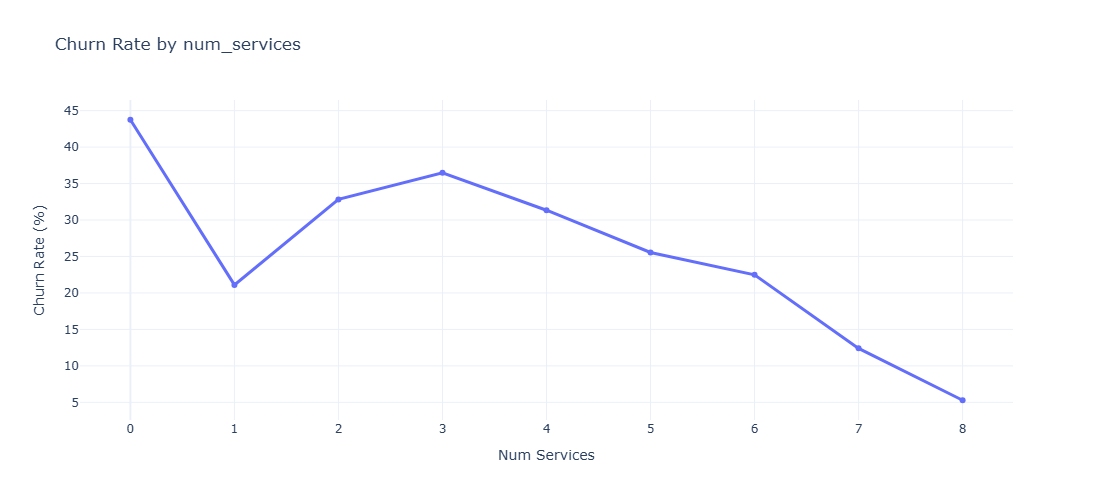

In [10]:
plot_numeric_churn(df_model, "num_services")

#### Business Interpretation

Customers with a larger number of subscribed services generally exhibit lower churn rates. This suggests that customers who rely on multiple products are more engaged with the provider and face higher switching costs.

Consequently, the total number of subscribed services provides a meaningful measure of customer engagement and is expected to improve churn prediction.

### Additional Feature 2: Protection score

Security and support services represent value-added offerings that strengthen customer relationships. Instead of treating each service independently, these related products were combined into a single protection score.

The protection score measures the number of protection-oriented services subscribed to by each customer.

In [11]:
protection_features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

df_model["protection_score"] = (
    df_model[protection_features]
    .apply(lambda row: row.isin(["Yes"]).sum(), axis=1)
)

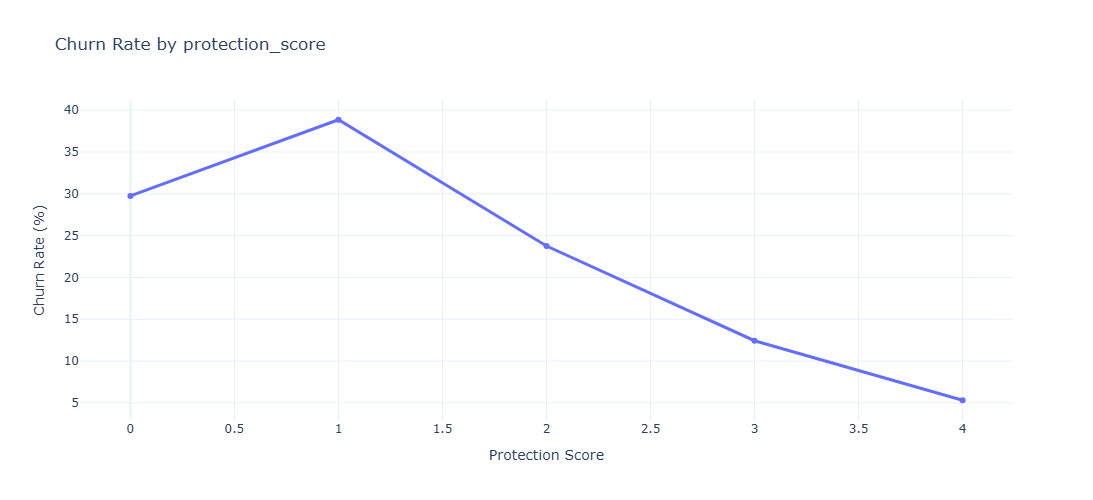

In [12]:
plot_numeric_churn(df_model, "protection_score")

#### Business Interpretation

Customers subscribing to multiple protection services tend to churn less frequently. This indicates that value-added services increase customer loyalty and strengthen long-term engagement with the provider.

The protection score therefore captures customer commitment more effectively than considering each protection service separately.

### Additioal Feature 3:Streaming score

Entertainment-related services were combined into a single feature representing the number of streaming products subscribed to by each customer.

This feature summarizes entertainment adoption while reducing the number of individual variables presented to the model.

In [13]:
streaming_features = [
    "StreamingTV",
    "StreamingMovies"
]

df_model["streaming_services"] = (
    df_model[streaming_features]
    .apply(lambda row: row.isin(["Yes"]).sum(), axis=1)
)

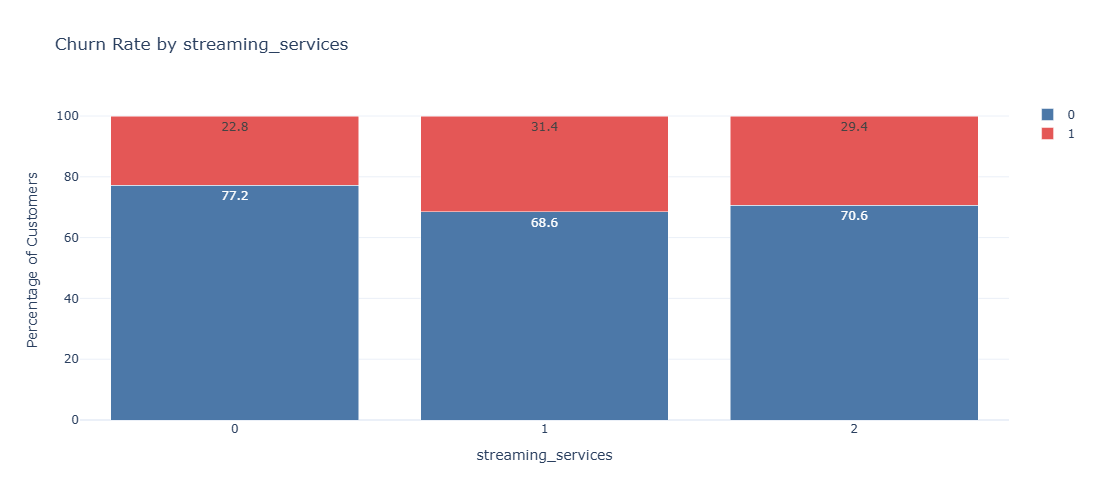

streaming_services
0    22.799097
1    31.430404
2    29.432990
Name: Churn, dtype: float64

In [39]:
plot_categorical_churn(df_model, "streaming_services")

#### Business Interpretation

The streaming services feature captures customers' adoption of entertainment products. Differences in churn across this feature indicate whether entertainment offerings contribute to customer retention or represent optional services with limited influence on customer loyalty.

### Additioal Feature 4: Fiber flag

Exploratory analysis showed that customers using fibre-optic internet exhibited different churn behaviour from customers using DSL or no internet service.

A binary feature was therefore created to explicitly identify fibre-optic customers.

In [15]:
df_model["is_fiber"] = (
    df_model["InternetService"] == "Fiber optic"
).astype(int)

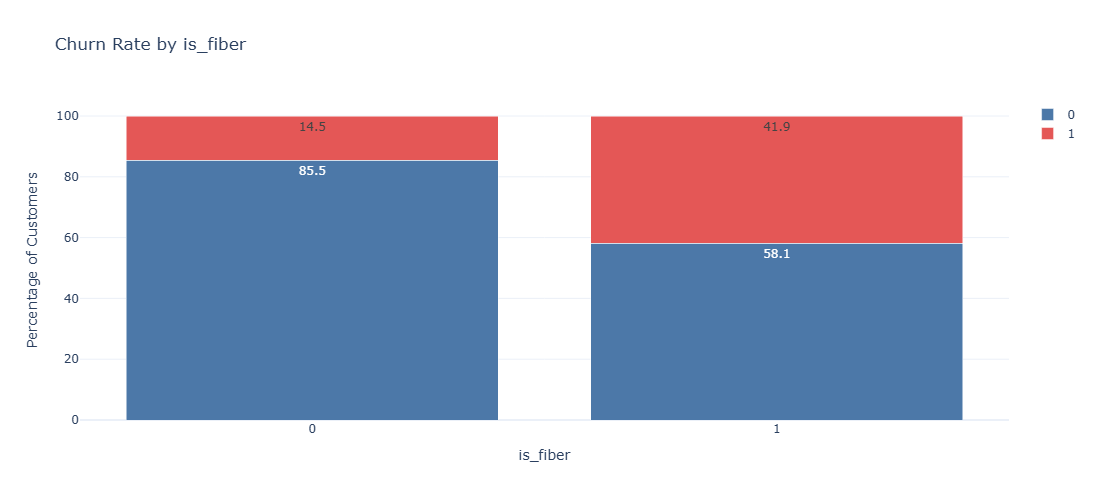

is_fiber
0    14.492019
1    41.892765
Name: Churn, dtype: float64

In [16]:
plot_categorical_churn(df_model, "is_fiber")

#### Business Interpretation

The fibre customer indicator isolates a customer segment that demonstrated distinct churn behaviour during exploratory analysis. Providing this information explicitly may simplify the learning task for tree-based models while improving model interpretability.

In [17]:
df_model["is_monthly_contract"] = (
    df_model["Contract"] == "Month-to-month"
).astype(int)

In [18]:
df_model["avg_monthly_spend"] = np.where(
    df_model["tenure"] > 0,
    df_model["TotalCharges"] / df_model["tenure"],
    0
)

## Additioal Feature 5: Tenure Group

The exploratory analysis indicated that customer churn is strongly associated with customer tenure. While the original `tenure` variable captures the number of months a customer has remained with the company, grouping customers into tenure bands can better represent distinct stages of the customer lifecycle.

The following engineered features were created to capture customer engagement, service adoption, and contract characteristics that may improve model performance while remaining easily interpretable from a business perspective.

In [19]:
df_model["tenure_group"] = pd.cut(
    df_model["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12",
        "13-24",
        "25-48",
        "49-72"
    ],
    include_lowest=True
)

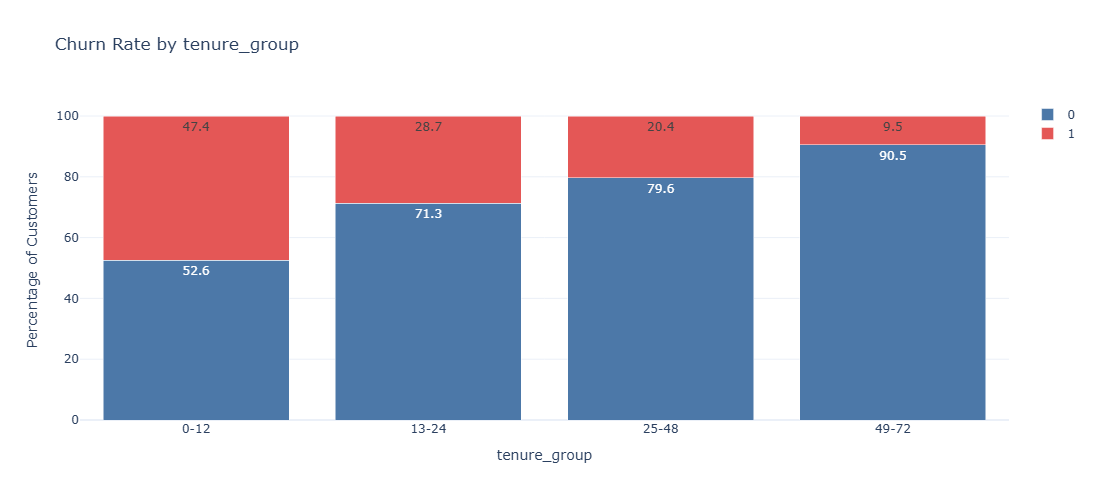

tenure_group
0-12     47.438243
13-24    28.710938
25-48    20.388959
49-72     9.513176
Name: Churn, dtype: float64

In [20]:
plot_categorical_churn(df_model, "tenure_group")

### Business Interpretation

The engineered tenure groups reveal a clear decline in churn as customer tenure increases. Nearly half of customers in their first year leave the service, while customers with more than four years of tenure exhibit churn rates below 10%.

This finding suggests that the first year represents the highest-risk period in the customer lifecycle. From a business perspective, onboarding, customer engagement, and early retention initiatives should therefore be prioritized during the first 12 months of a customer's subscription.

In [21]:
df_model["has_dependents_or_partner"] = (
    ((df_model["Dependents"] == "Yes") |
     (df_model["Partner"] == "Yes"))
    .astype(int)
)

In [22]:
new_features = [
    "num_services",
    "protection_score",
    "streaming_services",
    "is_fiber",
    "is_monthly_contract",
    "avg_monthly_spend",
    "tenure_group"
]

df_model[new_features].head()

,num_services,protection_score,streaming_services,is_fiber,is_monthly_contract,avg_monthly_spend,tenure_group
0,1,1,0,0,1,29.850000,0-12
1,3,2,0,0,0,55.573529,25-48
2,3,2,0,0,1,54.075000,0-12
3,3,3,0,0,0,40.905556,25-48
4,1,0,0,1,1,75.825000,0-12


In [23]:
df_model[new_features].describe(include="all")

,num_services,protection_score,streaming_services,is_fiber,is_monthly_contract,avg_monthly_spend,tenure_group
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043
unique,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,NaN,49-72
freq,NaN,NaN,NaN,NaN,NaN,NaN,2239
mean,3.362914,1.265654,0.772256,0.439585,0.550192,64.698218,NaN
std,2.062031,1.286879,0.852573,0.496372,0.497510,30.270670,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,1.000000,0.000000,0.000000,0.000000,0.000000,35.649000,NaN
50%,3.000000,1.000000,0.000000,0.000000,1.000000,70.300000,NaN
75%,5.000000,2.000000,2.000000,1.000000,1.000000,90.174158,NaN


In [24]:
pd.DataFrame({
    "Unique Values":
    df_model[categorical_features].nunique()
}).sort_values(
    "Unique Values",
    ascending=False
)

,Unique Values
PaymentMethod,4
InternetService,3
OnlineSecurity,3
DeviceProtection,3
TechSupport,3
OnlineBackup,3
MultipleLines,3
StreamingTV,3
StreamingMovies,3
Contract,3


### Feature Cardinality

All categorical variables contain between 2 and 4 unique categories, indicating low cardinality. Consequently, one-hot encoding was selected as the encoding strategy because it preserves interpretability while avoiding artificial ordinal relationships between categorical values.

No high-cardinality features requiring target encoding or embedding techniques were identified.

In [25]:
X = df_model.drop(
    columns="Churn"
)

y = df_model["Churn"]

## Preventing Data Leakage

Several design decisions were made to ensure unbiased model evaluation:

- The train/test split is performed before fitting any preprocessing transformations.
- Scaling parameters are learned only from the training data.
- Categorical encoding is fitted exclusively on the training set.
- Hyperparameter tuning uses cross-validation within the training data.
- The independent test set is used only once for final evaluation.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Machine Learning Pipeline

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [29]:
def build_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

In [30]:
log_reg_pipeline = build_pipeline(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
)

In [31]:
log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [32]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba)
    }

In [33]:
results = []

results.append(
    evaluate_model(
        log_reg_pipeline,
        X_test,
        y_test,
        "Logistic Regression"
    )
)

pd.DataFrame(results).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.738,0.504,0.783,0.614,0.842,0.633


## Baseline Model Performance

The Logistic Regression model provides a strong and interpretable baseline for churn prediction. To address the class imbalance observed during exploratory analysis, balanced class weights were applied during training.

Although this approach results in a modest reduction in overall accuracy, it substantially improves recall, enabling the model to identify a larger proportion of customers at risk of churning.

From a business perspective, correctly identifying potential churners is more valuable than maximizing overall accuracy, since missed churn cases represent lost opportunities for proactive retention.

In [34]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=4,
        learning_rate=0.05,
        loss_function="Logloss",
        verbose=False,
        random_state=42
    )
}

In [35]:
model_results = []

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")

    pipeline = build_pipeline(model)
    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    result = evaluate_model(
        pipeline,
        X_test,
        y_test,
        name
    )

    model_results.append(result)

results_df = (
    pd.DataFrame(model_results)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

results_df.round(3)

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training CatBoost...


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,CatBoost,0.808,0.671,0.540,0.599,0.845,0.662
1,Random Forest,0.757,0.528,0.794,0.635,0.843,0.652
2,XGBoost,0.798,0.648,0.527,0.581,0.842,0.652
3,Logistic Regression,0.738,0.504,0.783,0.614,0.842,0.633


## Model Benchmarking

Multiple classification models were compared using the same preprocessing pipeline and train/test split. This ensures that performance differences are driven by model behaviour rather than inconsistent preprocessing.

The models evaluated include:

- Logistic Regression as an interpretable baseline
- Random Forest as a non-linear ensemble model
- XGBoost as a gradient boosting model
- CatBoost as a boosting model designed to handle categorical patterns effectively

## Model Comparison

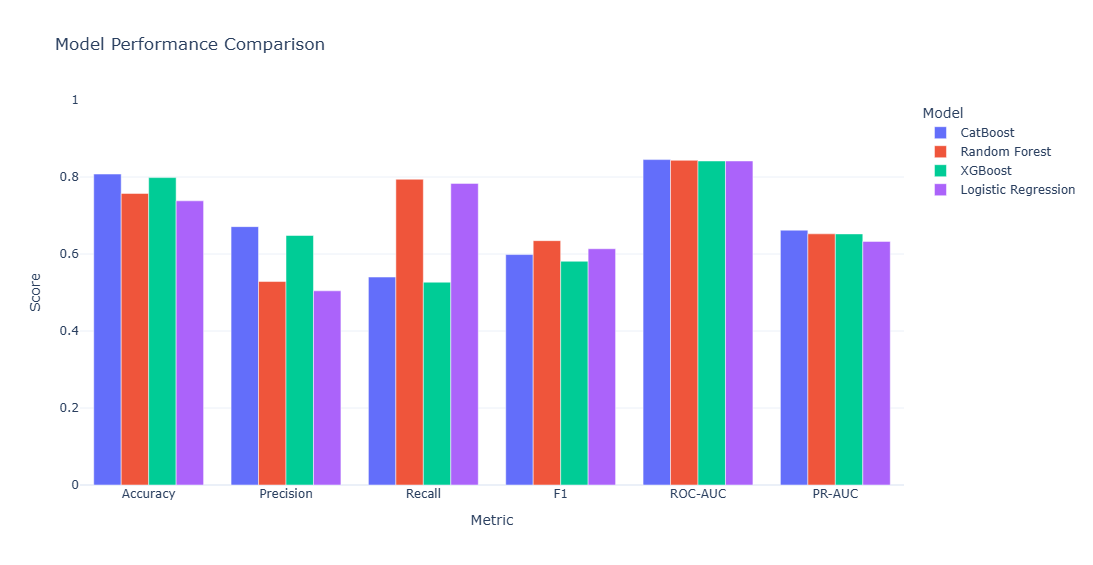

In [36]:
results_long = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

fig = px.bar(
    results_long,
    x="Metric",
    y="Score",
    color="Model",
    barmode="group",
    template="plotly_white",
    title="Model Performance Comparison"
)

fig.update_layout(
    width=1100,
    height=550,
    yaxis=dict(range=[0,1])
)

fig.show()

### Model Comparison

No single model dominates across every evaluation metric.

- Logistic Regression achieves strong recall while remaining highly interpretable.
- Random Forest provides the highest recall and F1-score, making it suitable when identifying as many churning customers as possible is the primary objective.
- CatBoost achieves the highest precision, ROC-AUC and PR-AUC, making it the strongest overall probabilistic classifier.
- XGBoost performs competitively but offers no clear advantage over CatBoost on this dataset.

## Model Selection Summary

| Business Objective      | Recommended Model   | Reason                                                  |
| ----------------------- | ------------------- | ------------------------------------------------------- |
| Highest Recall          | Random Forest       | Identifies the largest proportion of churning customers |
| Highest Precision       | CatBoost            | Minimizes unnecessary retention actions                 |
| Highest Overall Ranking | CatBoost            | Best ROC-AUC and PR-AUC                                 |
| Most Interpretable      | Logistic Regression | Transparent coefficients and easy explanation           |


## Why Accuracy Alone Is Insufficient

Customer churn prediction is an imbalanced classification problem. A model that predicts every customer as retained would achieve high accuracy while failing to identify customers who are most likely to leave.

For this reason, model evaluation focuses primarily on:

- Recall
- Precision
- PR-AUC
- ROC-AUC

rather than overall accuracy.

In [37]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(trained_models["CatBoost"], "../models/catboost_pipeline.pkl")
joblib.dump(trained_models["Random Forest"], "../models/random_forest_pipeline.pkl")
joblib.dump(trained_models["Logistic Regression"], "../models/logistic_regression_pipeline.pkl")
joblib.dump(trained_models["XGBoost"], "../models/xgboost_pipeline.pkl")

X_test.to_csv("../data/processed/X_test.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)